*Team X* : Stock Price Prediction Using Linear Regression and Random Forest

# 1. Getting the required packages

We first have to install the following packages using pip.
- package `Yahoo Finance`.
- `matplotlib`

In [4]:
# installation of packages
# uncomment below if packages are not already installed in your local environment

!pip install numpy pandas
!pip install matplotlib
!pip install yfinance


[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/949.0 kB ? eta -:--:--
     ---------------------------------------- 0.0/949.0 kB ? eta -:--:--
     ----------- ---------------------------- 262.1/949.0 kB ? eta -:--:--
     ------------------- ---------------- 524.3/949.0 kB 932.9 kB/s eta 0:00:01
     ----------------------------- ------ 786.4/949.0 kB 960.2 kB/s eta 0:00:01
     -------------------------------------- 949.0/949.0 kB 1.0 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for peewee: filename=peewee-3.18.0-py3-none-any.whl size=139099 sha256=ffe03c0496d820183771d46638ce306b3b59ae019e426302c3e9081ffe687877
  Stored in directory: c:\users\abhig\appdata\local\pip\c


[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


A `!` mark is needed before `pip` for shell command. If you are installing it in your local machine from command line interface (CLI), then you don't need this exclamation (`!`) mark.  

In [5]:
# Data Analysis
import numpy as np
import pandas as pd


# Financial Data Retrieval
import yfinance as yf

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Model Training
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error, r2_score, mean_absolute_error, median_absolute_error

In [6]:
import warnings
import itertools
warnings.filterwarnings("ignore")

# 2. Getting the dataset

- We will Fetch the dataset from https://finance.yahoo.com/lookup/
  1. Go through the link Above ⤴️
  2. Copy the ticker ex: TSLA for Tesla

In [7]:
import yfinance as yf

# Get stock ticker from: https://finance.yahoo.com/lookup/
# Ex: TSLA

ticker = input("Enter the stock ticker: ")

# Time Period
S = '2023-01-01'
E = '2024-12-07'

df = yf.download(ticker, start = S, end = E)

In [6]:
#print first 5 rows of the datatset
df.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,JWL.NS,JWL.NS,JWL.NS,JWL.NS,JWL.NS,JWL.NS
Date,,,,,,
2023-01-02,95.892509,96.349998,96.349998,92.349998,92.400002,507861
2023-01-03,98.430412,98.900002,101.099998,97.000000,100.000000,845390
2023-01-04,103.058334,103.550003,103.800003,97.349998,99.599998,971511
2023-01-05,99.027565,99.500000,103.349998,98.400002,101.849998,542960
2023-01-06,98.529938,99.000000,102.000000,98.500000,99.199997,246397


In the above dataset,
- `Date` will be in yyyy-mm-dd format
- Now, Saving the file.

In [7]:
# Save the DataFrame to a CSV file with the ticker name
file_name = f"{ticker}.csv"
df.to_csv(file_name, index=False)
print("Data saved to " + file_name)

Data saved to JWL.NS.csv


In [8]:
# Check dataset with .csv extension is there in the directory
!ls

'ls' is not recognized as an internal or external command,
operable program or batch file.


## Getting to know the dataset

In [9]:
# Type of the dataset.
df.dtypes

Price      Ticker
Adj Close  JWL.NS    float64
Close      JWL.NS    float64
High       JWL.NS    float64
Low        JWL.NS    float64
Open       JWL.NS    float64
Volume     JWL.NS      int64
dtype: object

We see above that, all features are numerics except, date. This makes sense. All features have their datatype as expected.

In [10]:
# Summary Statistics
df.describe().round(2)

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,JWL.NS,JWL.NS,JWL.NS,JWL.NS,JWL.NS,JWL.NS
count,475.00,475.00,475.00,475.00,475.00,475.00
mean,340.41,341.35,350.44,334.05,342.67,1524387.34
std,177.18,177.43,182.24,173.58,178.02,1993371.66
min,85.64,86.05,90.00,85.20,86.05,0.00
25%,163.15,163.93,167.57,155.97,159.32,569340.00
50%,340.68,341.85,349.90,336.00,343.70,988310.00
75%,490.50,491.00,503.05,482.40,491.68,1807002.00
max,728.12,730.00,748.10,716.00,736.60,26291274.00


In [11]:
# Getting the basic information about the dataset:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 475 entries, 2023-01-02 to 2024-12-06
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   (Adj Close, JWL.NS)  475 non-null    float64
 1   (Close, JWL.NS)      475 non-null    float64
 2   (High, JWL.NS)       475 non-null    float64
 3   (Low, JWL.NS)        475 non-null    float64
 4   (Open, JWL.NS)       475 non-null    float64
 5   (Volume, JWL.NS)     475 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 26.0 KB


In [12]:
df.shape

(475, 6)

# 3. Basic formatting of the dataset

### Missing Values

In [13]:
# Getting the sum count of missing values in each column:
df.isnull().sum()

Price      Ticker
Adj Close  JWL.NS    0
Close      JWL.NS    0
High       JWL.NS    0
Low        JWL.NS    0
Open       JWL.NS    0
Volume     JWL.NS    0
dtype: int64

We have very small amount of missing data. We can just ignore them by deleting the missing values.

In [14]:
df = df.dropna()

# 4. Feature Engineering

Adding Feature:
1. Moving Averages
2. Relative Strength Index
3. Daily Change of price percentage.

In [15]:
# Moving Averages 10, 50, 200
df['MA10'] = df['Close'].rolling(window=10).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA200'] = df['Close'].rolling(window=200).mean()

# Relative Strength Index
df['RSI'] = 100 - (100 / (1 + df['Close'].diff().clip(lower=0).rolling(window=14).mean() / df['Close'].diff().clip(upper=0).abs().rolling(window=14).mean()))

# Change in Price Percentage Daily.
df['daily_change'] = df['Close'].pct_change()

# Dropping rows with NaN values due to rolling calculations
df = df.dropna()


In [16]:
df.head()

Price,Adj Close,Close,High,Low,Open,Volume,MA10,MA50,MA200,RSI,daily_change
Ticker,JWL.NS,JWL.NS,JWL.NS,JWL.NS,JWL.NS,JWL.NS,,,,,
Date,,,,,,,,,,,
2023-10-23,294.291351,295.299988,315.950012,294.950012,315.000000,632767,307.495007,321.028002,175.93850,39.891304,-0.048800
2023-10-25,279.840881,280.799988,300.799988,280.549988,292.000000,731108,305.865005,321.937001,176.86075,31.635658,-0.049103
2023-10-26,293.793030,294.799988,294.799988,266.799988,279.049988,1676552,304.150003,322.891001,177.84025,41.636691,0.049858
2023-10-27,308.442871,309.500000,309.500000,303.899994,309.500000,753321,303.305002,323.892001,178.87000,48.121498,0.049864
2023-10-30,315.867432,316.950012,324.950012,313.149994,324.950012,2199581,303.805002,324.783001,179.95725,57.894740,0.024071


In [17]:
df.tail()

Price,Adj Close,Close,High,Low,Open,Volume,MA10,MA50,MA200,RSI,daily_change
Ticker,JWL.NS,JWL.NS,JWL.NS,JWL.NS,JWL.NS,JWL.NS,,,,,
Date,,,,,,,,,,,
2024-12-02,496.799988,496.799988,502.799988,486.100006,491.000000,962697,459.529996,490.781998,504.387751,50.900467,0.012328
2024-12-03,489.899994,489.899994,503.299988,488.750000,497.899994,638685,464.879996,490.228998,504.943751,56.885597,-0.013889
2024-12-04,493.750000,493.750000,511.950012,489.299988,492.350006,1517419,470.174997,489.519998,505.546001,63.891005,0.007859
2024-12-05,484.700012,484.700012,498.600006,481.600006,494.899994,1091348,475.964999,488.425998,506.248001,68.174486,-0.018329
2024-12-06,493.049988,493.049988,495.899994,483.200012,486.899994,833651,482.809998,487.811998,506.981251,72.094838,0.017227


# 5. Splitting the dataset

**REMEMBER** We don't shuffle data in time-series unlike usual tabular data, because if we shuffle, then the model may know the future data by mistake causing data-leakage.

We'll splitt the data into train and test (80/20).

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
# Split the data into training (80%) and testing (20%) sets
df_train, df_test = train_test_split(df, test_size=0.2, shuffle = False)

In [20]:
df_train.tail()

Price,Adj Close,Close,High,Low,Open,Volume,MA10,MA50,MA200,RSI,daily_change
Ticker,JWL.NS,JWL.NS,JWL.NS,JWL.NS,JWL.NS,JWL.NS,,,,,
Date,,,,,,,,,,,
2024-09-10,510.059601,511.100006,516.000000,489.600006,511.299988,1638483,547.355014,604.190002,462.982751,31.327662,0.005113
2024-09-11,522.733704,523.799988,528.700012,508.000000,511.100006,988249,543.470010,600.827001,464.033251,39.607843,0.024848
2024-09-12,523.432312,524.500000,533.799988,518.650024,526.799988,664012,540.075009,597.674001,465.009001,40.013060,0.001336
2024-09-13,558.061707,559.200012,568.000000,525.849976,528.150024,2127280,538.430008,594.996002,466.076001,54.390935,0.066158
2024-09-16,544.090210,545.200012,568.099976,542.099976,563.200012,910290,537.380008,591.476002,467.107001,46.138505,-0.025036


In [21]:
df_test.head()

Price,Adj Close,Close,High,Low,Open,Volume,MA10,MA50,MA200,RSI,daily_change
Ticker,JWL.NS,JWL.NS,JWL.NS,JWL.NS,JWL.NS,JWL.NS,,,,,
Date,,,,,,,,,,,
2024-09-17,531.366150,532.450012,553.500000,521.450012,548.799988,1821621,535.910007,587.525002,468.092751,41.806833,-0.023386
2024-09-18,533.212341,534.299988,546.799988,527.000000,534.000000,991273,533.710007,583.738001,469.131001,43.363553,0.003474
2024-09-19,516.496460,517.549988,541.000000,511.000000,536.450012,1101939,530.375003,580.090001,470.022751,33.994475,-0.031349
2024-09-20,528.122742,529.200012,547.299988,518.299988,520.000000,1699655,528.580002,576.917001,471.003251,42.349882,0.022510
2024-09-23,538.302002,539.400024,541.500000,530.650024,534.000000,754471,531.670004,573.918002,472.004501,47.783814,0.019274


We see above that splitting is done successfully without random shuffling.

In [22]:
len(df_train), len(df_test),  len(df_train), len(df_train)+\
len(df_test), len(df)

(220, 56, 220, 276, 276)

Above we see that lengths of the dataframes after after splitting are consistent.

# Exploratory Data Analysis (EDA) on training dataset

In [23]:
df_train.head()

Price,Adj Close,Close,High,Low,Open,Volume,MA10,MA50,MA200,RSI,daily_change
Ticker,JWL.NS,JWL.NS,JWL.NS,JWL.NS,JWL.NS,JWL.NS,,,,,
Date,,,,,,,,,,,
2023-10-23,294.291351,295.299988,315.950012,294.950012,315.000000,632767,307.495007,321.028002,175.93850,39.891304,-0.048800
2023-10-25,279.840881,280.799988,300.799988,280.549988,292.000000,731108,305.865005,321.937001,176.86075,31.635658,-0.049103
2023-10-26,293.793030,294.799988,294.799988,266.799988,279.049988,1676552,304.150003,322.891001,177.84025,41.636691,0.049858
2023-10-27,308.442871,309.500000,309.500000,303.899994,309.500000,753321,303.305002,323.892001,178.87000,48.121498,0.049864
2023-10-30,315.867432,316.950012,324.950012,313.149994,324.950012,2199581,303.805002,324.783001,179.95725,57.894740,0.024071


In [24]:
df_train.isnull().sum()

Price         Ticker
Adj Close     JWL.NS    0
Close         JWL.NS    0
High          JWL.NS    0
Low           JWL.NS    0
Open          JWL.NS    0
Volume        JWL.NS    0
MA10                    0
MA50                    0
MA200                   0
RSI                     0
daily_change            0
dtype: int64

We have negligible number od missing values. We'll neglect them for now.

Let's plot the variable `volume` over time

Text(0.5, 1.0, 'JWL.NS Volume Over Time')

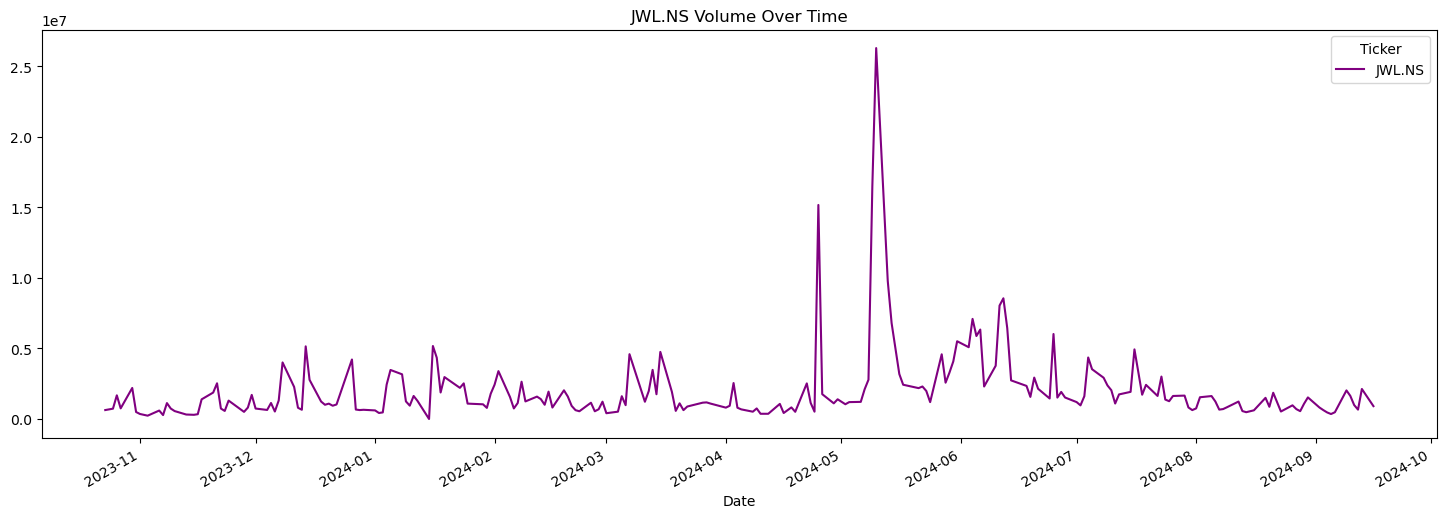

In [25]:
df_train.Volume.plot(figsize=(18, 6), color='purple')
plt.title(ticker + ' Volume Over Time')

### What is the trend in closing price of stock (adj_close) with time?

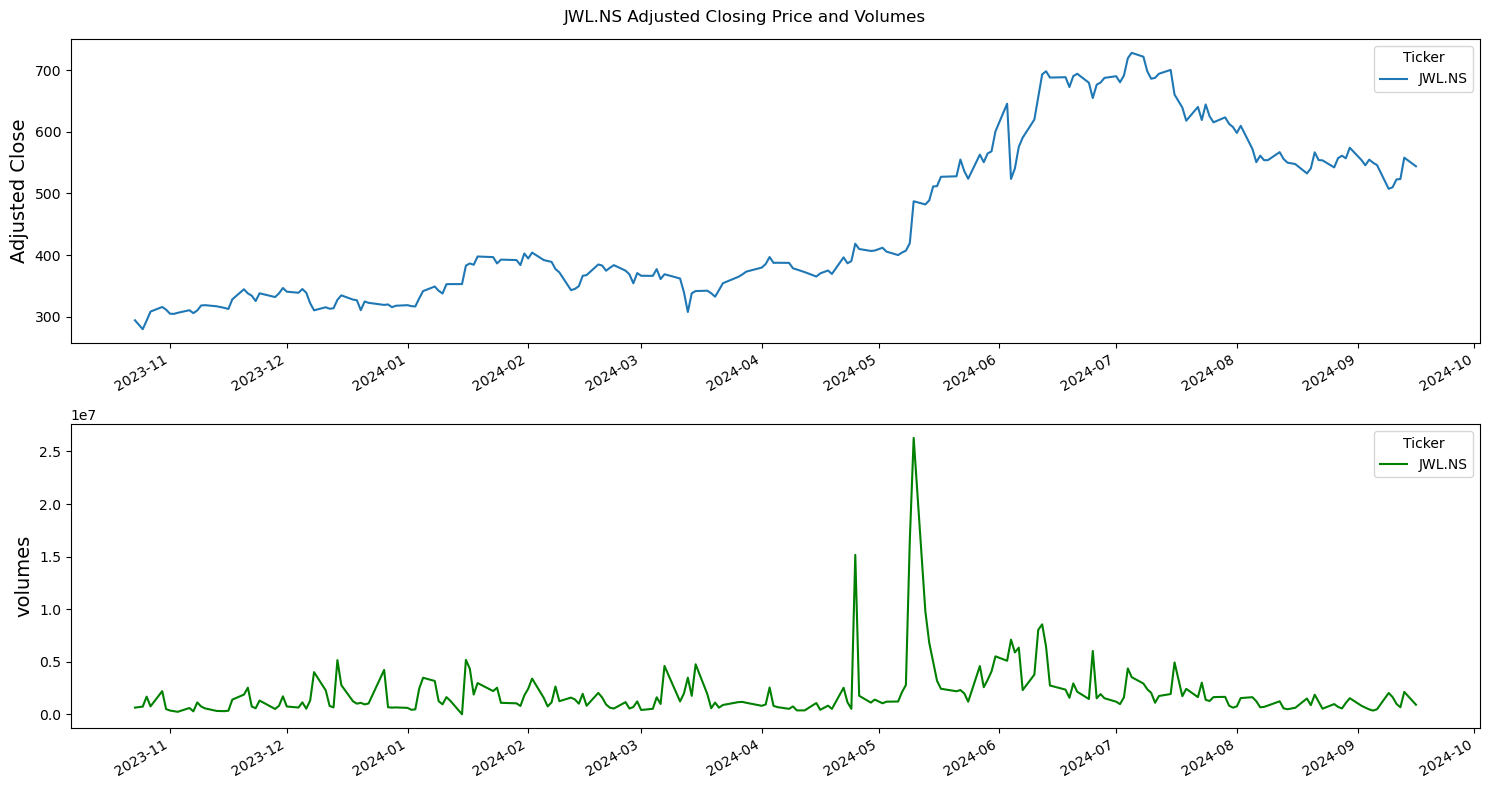

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Plotting adjusted closing price:
df_train['Adj Close'].plot(ax=axes[0])
axes[0].set_xlabel('')
axes[0].set_ylabel('Adjusted Close',fontsize=14)

# Creating a line plot for Volumes:
df_train['Volume'].plot(ax=axes[1], color = 'green')
axes[1].set_ylabel('volumes', fontsize=14)
axes[1].set_xlabel('')  # to get nothing in x axis as labels

plt.suptitle(ticker + ' Adjusted Closing Price and Volumes')
plt.tight_layout()
plt.show()



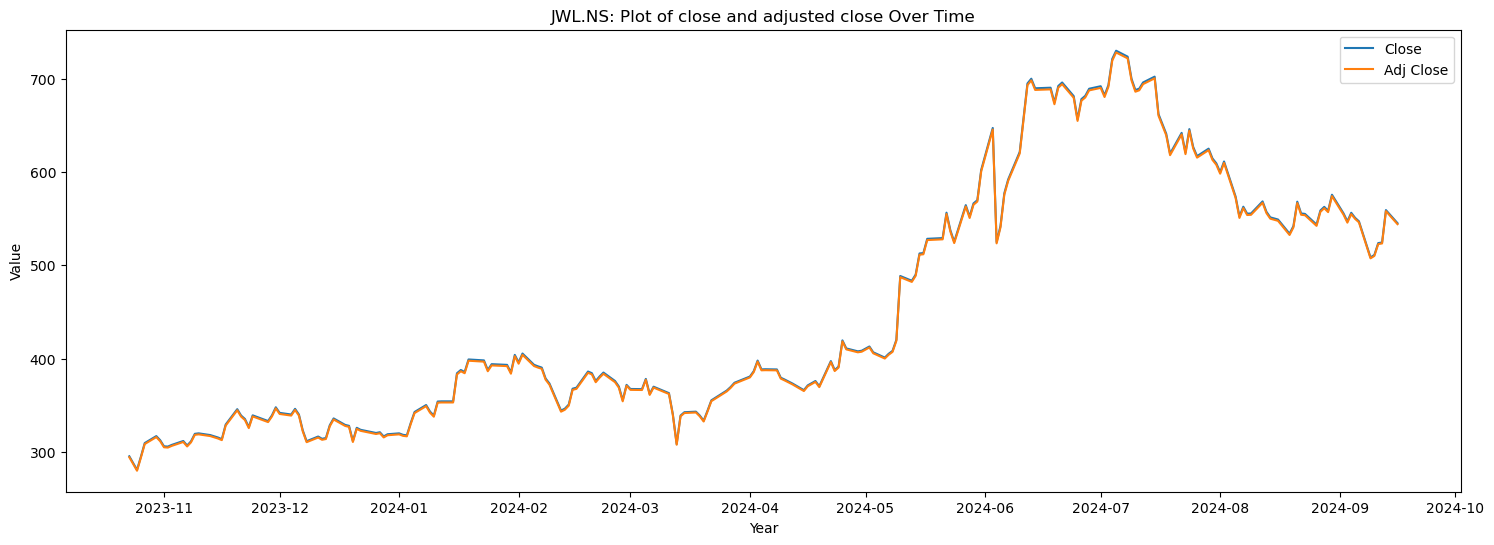

In [27]:
plt.figure(figsize=(18, 6))

# Plot the columns using matplotlib
plt.plot(df_train.index, df_train['Close'], label="Close")
plt.plot(df_train.index, df_train['Adj Close'], label="Adj Close")

# Add a legend, axis labels, and title
plt.legend()
plt.xlabel("Year")
plt.ylabel("Value")
plt.title(ticker + ": Plot of close and adjusted close Over Time")


# Show the plot
plt.show()




We see in the above figure that close and adjusted close follows the same trend.

Next we'll see how `open` and `close` compared in the same plot.

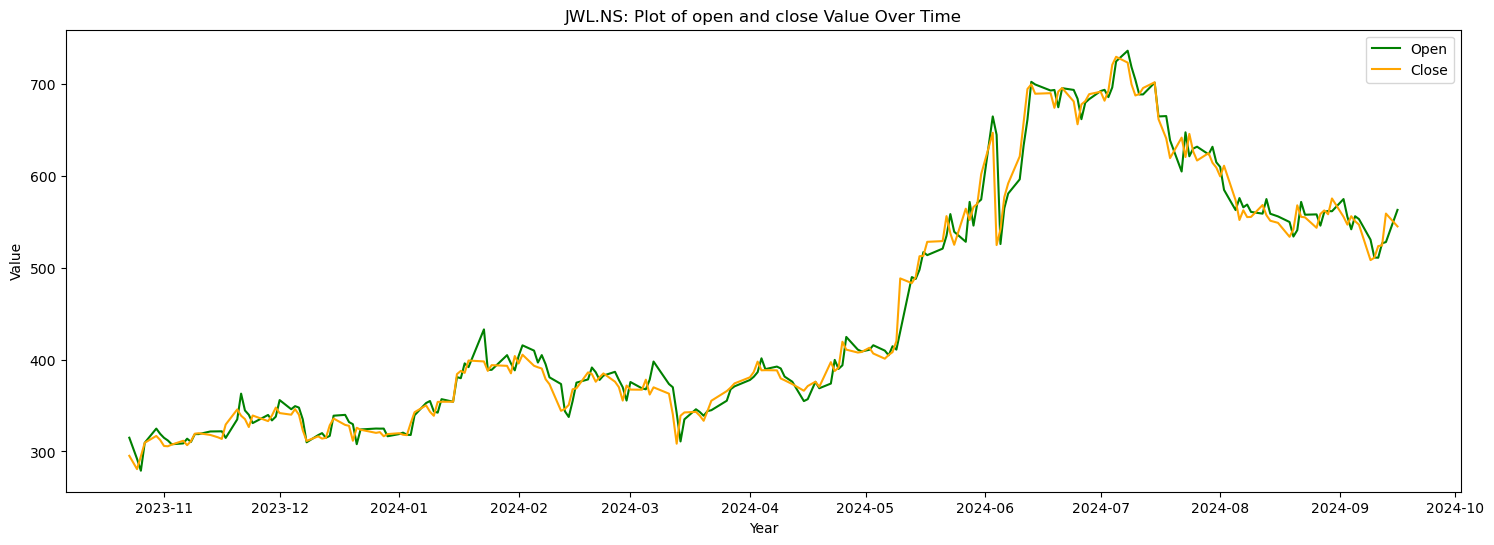

In [28]:
plt.figure(figsize=(18, 6))
# Plot the columns using matplotlib
plt.plot(df_train.index, df_train['Open'], label="Open", color="green")
plt.plot(df_train.index, df_train['Close'], label="Close", color="orange")

# Add a legend, axis labels, and title
plt.legend()
plt.xlabel("Year")
plt.ylabel("Value")
plt.title(ticker + ": Plot of open and close Value Over Time")

# Show the plot
plt.show()

Open and close are almost indstiguisable at this scale with bare eye.

Now we'll plot open, close, high and low in the same plot.

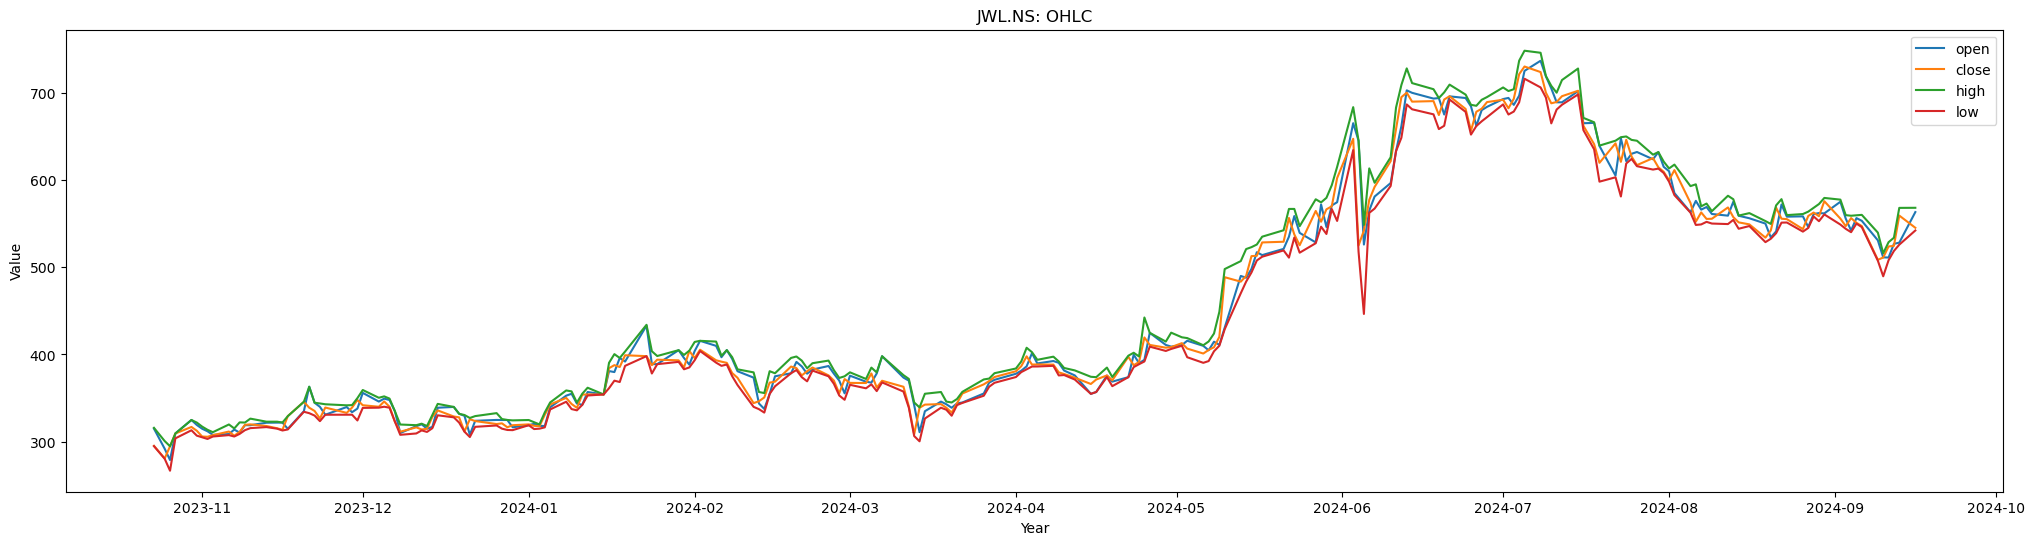

In [29]:
plt.figure(figsize=(25, 6))

# Plot the columns using matplotlib
plt.plot(df_train.index, df_train['Open'], label="open")
plt.plot(df_train.index, df_train['Close'], label="close")
plt.plot(df_train.index, df_train['High'], label="high")
plt.plot(df_train.index, df_train['Low'], label="low")

# Add a legend, axis labels, and title
plt.legend()
plt.xlabel("Year")
plt.ylabel("Value")
plt.title(ticker + ": OHLC")

# Show the plot
plt.show()

- Sometimes high in green are visible. All of them folllow the same trend at this scale.

### Moving average Plotting on training Data

This is done to smoothen the data. 50 day and 200 days moving averages are common among traders and investors.

In [30]:
df_train.head()

Price,Adj Close,Close,High,Low,Open,Volume,MA10,MA50,MA200,RSI,daily_change
Ticker,JWL.NS,JWL.NS,JWL.NS,JWL.NS,JWL.NS,JWL.NS,,,,,
Date,,,,,,,,,,,
2023-10-23,294.291351,295.299988,315.950012,294.950012,315.000000,632767,307.495007,321.028002,175.93850,39.891304,-0.048800
2023-10-25,279.840881,280.799988,300.799988,280.549988,292.000000,731108,305.865005,321.937001,176.86075,31.635658,-0.049103
2023-10-26,293.793030,294.799988,294.799988,266.799988,279.049988,1676552,304.150003,322.891001,177.84025,41.636691,0.049858
2023-10-27,308.442871,309.500000,309.500000,303.899994,309.500000,753321,303.305002,323.892001,178.87000,48.121498,0.049864
2023-10-30,315.867432,316.950012,324.950012,313.149994,324.950012,2199581,303.805002,324.783001,179.95725,57.894740,0.024071


In [31]:
df_train.tail()

Price,Adj Close,Close,High,Low,Open,Volume,MA10,MA50,MA200,RSI,daily_change
Ticker,JWL.NS,JWL.NS,JWL.NS,JWL.NS,JWL.NS,JWL.NS,,,,,
Date,,,,,,,,,,,
2024-09-10,510.059601,511.100006,516.000000,489.600006,511.299988,1638483,547.355014,604.190002,462.982751,31.327662,0.005113
2024-09-11,522.733704,523.799988,528.700012,508.000000,511.100006,988249,543.470010,600.827001,464.033251,39.607843,0.024848
2024-09-12,523.432312,524.500000,533.799988,518.650024,526.799988,664012,540.075009,597.674001,465.009001,40.013060,0.001336
2024-09-13,558.061707,559.200012,568.000000,525.849976,528.150024,2127280,538.430008,594.996002,466.076001,54.390935,0.066158
2024-09-16,544.090210,545.200012,568.099976,542.099976,563.200012,910290,537.380008,591.476002,467.107001,46.138505,-0.025036


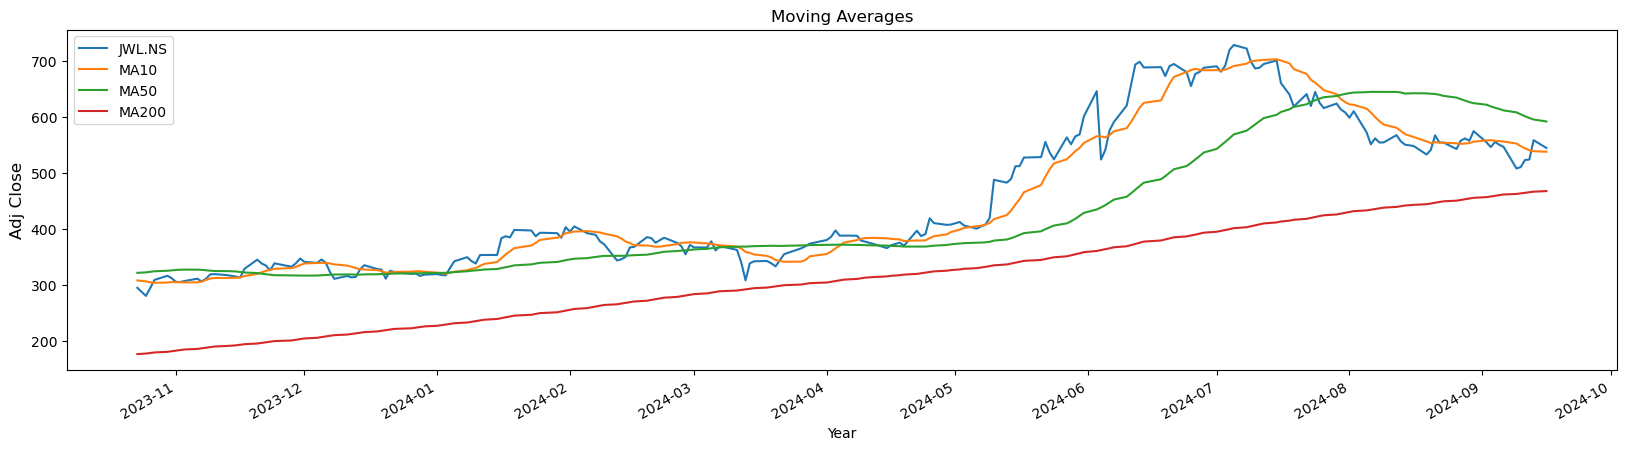

In [32]:
df_train['Adj Close'].plot(figsize = (20,5))
df_train['MA10'].plot()
df_train['MA50'].plot()
df_train['MA200'].plot()
plt.xlabel('Year')
plt.ylabel('Adj Close', fontsize=12)
plt.title('Moving Averages')
plt.legend()
plt.show()

Observations:<br>
    - Moving averages have an smoothening effect on adj_close<br>
    - 200 day moving average is smoother than moving average 50<br>
    - Higher moving average has higher lag<br>

### Daily Average Return (DAR)

The daily average return for a stock is the average gain or loss that a stock has experienced over a given period, usually expressed as a percentage of the stock's price. It is calculated by dividing the total return of a stock over a period of time by the number of trading days in that period.

For example, if a stock had an adjusted close price of Rs. 100 on Monday and Rs. 102 on Tuesday, its daily return for Tuesday would be:

(102 - 100) / 100 = 0.02 = 2%

To calculate the average daily return over a period of, say, 30 trading days, you would sum the daily returns for each of the 30 days, then divide the sum by 30.

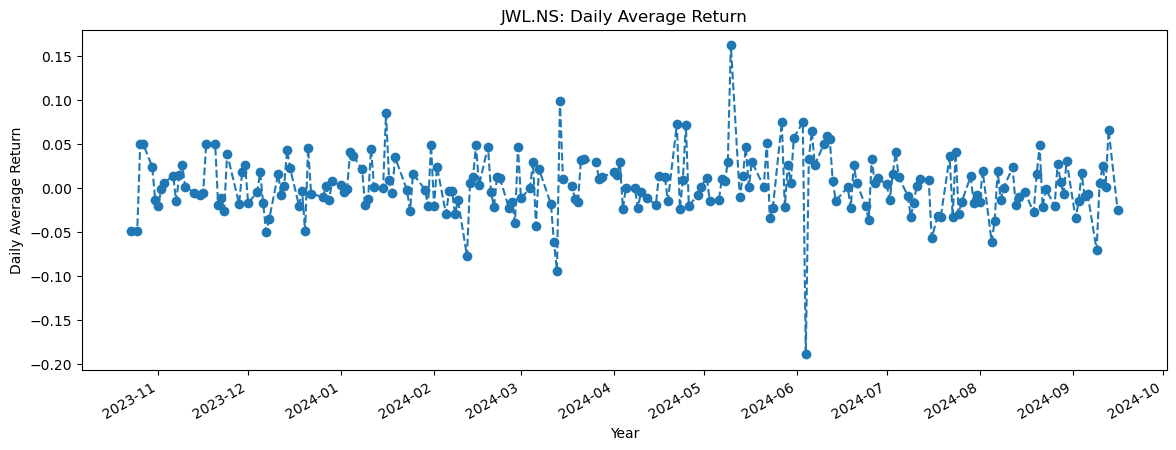

In [33]:
# Calculating the returns using the pct_change() function.pct means percent
df_train['daily_change'].plot(figsize=(14,5),linestyle='--',marker='o')
plt.xlabel('Year')
plt.ylabel('Daily Average Return')
plt.title(ticker + ": Daily Average Return")
plt.show()

In [34]:
# Adding Year, Month, and Weekday to df_train
df_train['Year'] = df_train.index.year
df_train['Month'] = df_train.index.month_name()
df_train['Weekday'] = df_train.index.day_name()


In [35]:
df_train.head()

Price,Adj Close,Close,High,Low,Open,Volume,MA10,MA50,MA200,RSI,daily_change,Year,Month,Weekday
Ticker,JWL.NS,JWL.NS,JWL.NS,JWL.NS,JWL.NS,JWL.NS,,,,,,,,
Date,,,,,,,,,,,,,,
2023-10-23,294.291351,295.299988,315.950012,294.950012,315.000000,632767,307.495007,321.028002,175.93850,39.891304,-0.048800,2023,October,Monday
2023-10-25,279.840881,280.799988,300.799988,280.549988,292.000000,731108,305.865005,321.937001,176.86075,31.635658,-0.049103,2023,October,Wednesday
2023-10-26,293.793030,294.799988,294.799988,266.799988,279.049988,1676552,304.150003,322.891001,177.84025,41.636691,0.049858,2023,October,Thursday
2023-10-27,308.442871,309.500000,309.500000,303.899994,309.500000,753321,303.305002,323.892001,178.87000,48.121498,0.049864,2023,October,Friday
2023-10-30,315.867432,316.950012,324.950012,313.149994,324.950012,2199581,303.805002,324.783001,179.95725,57.894740,0.024071,2023,October,Monday


### Correlation matrix

In [36]:
df_train_corr = df_train.copy()
df_train_corr.head()

Price,Adj Close,Close,High,Low,Open,Volume,MA10,MA50,MA200,RSI,daily_change,Year,Month,Weekday
Ticker,JWL.NS,JWL.NS,JWL.NS,JWL.NS,JWL.NS,JWL.NS,,,,,,,,
Date,,,,,,,,,,,,,,
2023-10-23,294.291351,295.299988,315.950012,294.950012,315.000000,632767,307.495007,321.028002,175.93850,39.891304,-0.048800,2023,October,Monday
2023-10-25,279.840881,280.799988,300.799988,280.549988,292.000000,731108,305.865005,321.937001,176.86075,31.635658,-0.049103,2023,October,Wednesday
2023-10-26,293.793030,294.799988,294.799988,266.799988,279.049988,1676552,304.150003,322.891001,177.84025,41.636691,0.049858,2023,October,Thursday
2023-10-27,308.442871,309.500000,309.500000,303.899994,309.500000,753321,303.305002,323.892001,178.87000,48.121498,0.049864,2023,October,Friday
2023-10-30,315.867432,316.950012,324.950012,313.149994,324.950012,2199581,303.805002,324.783001,179.95725,57.894740,0.024071,2023,October,Monday


In [37]:
df_train_corr = df_train_corr.drop(['MA50','MA200','daily_change','Year','Month','Weekday'],axis=1)
df_train_corr.head()

Price,Adj Close,Close,High,Low,Open,Volume,MA10,RSI
Ticker,JWL.NS,JWL.NS,JWL.NS,JWL.NS,JWL.NS,JWL.NS,,
Date,,,,,,,,
2023-10-23,294.291351,295.299988,315.950012,294.950012,315.000000,632767,307.495007,39.891304
2023-10-25,279.840881,280.799988,300.799988,280.549988,292.000000,731108,305.865005,31.635658
2023-10-26,293.793030,294.799988,294.799988,266.799988,279.049988,1676552,304.150003,41.636691
2023-10-27,308.442871,309.500000,309.500000,303.899994,309.500000,753321,303.305002,48.121498
2023-10-30,315.867432,316.950012,324.950012,313.149994,324.950012,2199581,303.805002,57.894740


Above correleation matrix plot is not very insightful, as most of them have correlation coefficient of 1. We'll look into how how the differences correlate with volume.

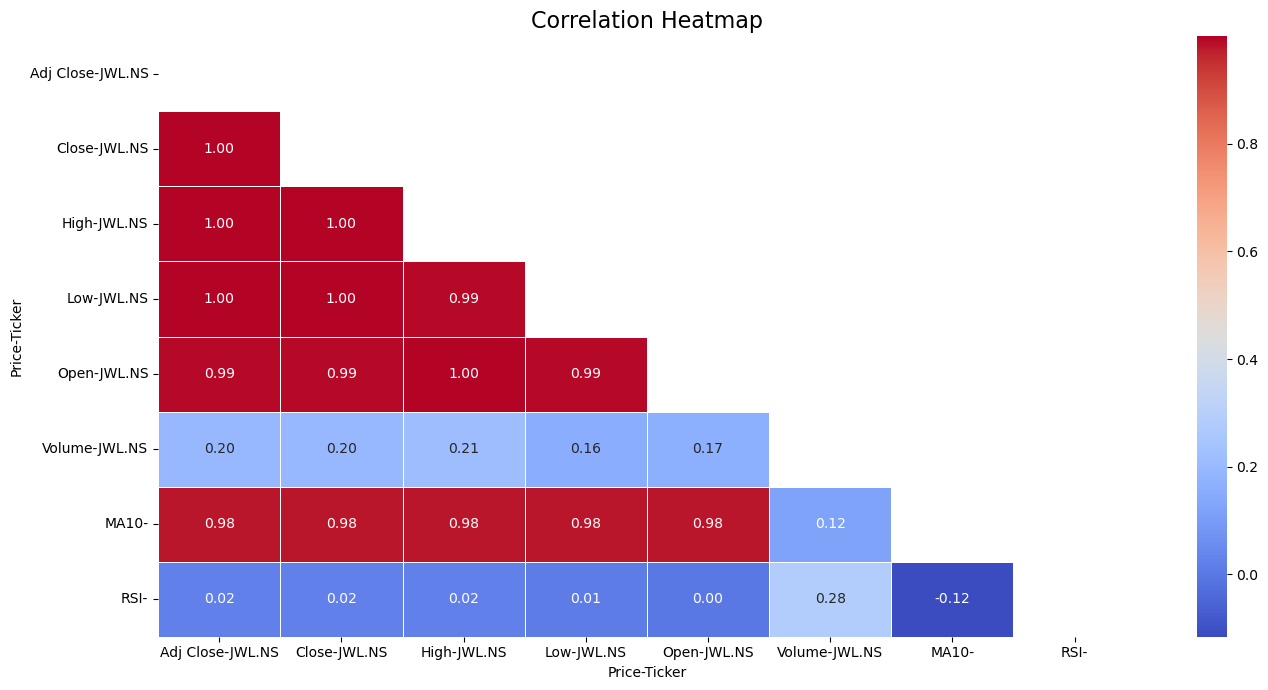

In [38]:
# Calculate the correlation matrix
corrM = df_train_corr.corr()

# Set up the figure size
plt.figure(figsize=(14, 7))

# Create a mask to hide the upper triangle of the correlation matrix
mask = np.zeros_like(corrM, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Plot the heatmap
sns.heatmap(corrM, annot=True, fmt=".2f", cmap="coolwarm", mask=mask, cbar=True, linewidths=0.5)

# Show the plot
plt.title("Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

In [39]:
df_train_corr_diff = df_train_corr.copy()
df_train_corr_diff.head()

Price,Adj Close,Close,High,Low,Open,Volume,MA10,RSI
Ticker,JWL.NS,JWL.NS,JWL.NS,JWL.NS,JWL.NS,JWL.NS,,
Date,,,,,,,,
2023-10-23,294.291351,295.299988,315.950012,294.950012,315.000000,632767,307.495007,39.891304
2023-10-25,279.840881,280.799988,300.799988,280.549988,292.000000,731108,305.865005,31.635658
2023-10-26,293.793030,294.799988,294.799988,266.799988,279.049988,1676552,304.150003,41.636691
2023-10-27,308.442871,309.500000,309.500000,303.899994,309.500000,753321,303.305002,48.121498
2023-10-30,315.867432,316.950012,324.950012,313.149994,324.950012,2199581,303.805002,57.894740


Observations:<br>

- it is more useful than the previous heatmap
- highest correlation of volume traded is with high-low. It makes sense because higher is the change in stock price, more activities in the market.

### Visualization: Adj Close and Monthly mean

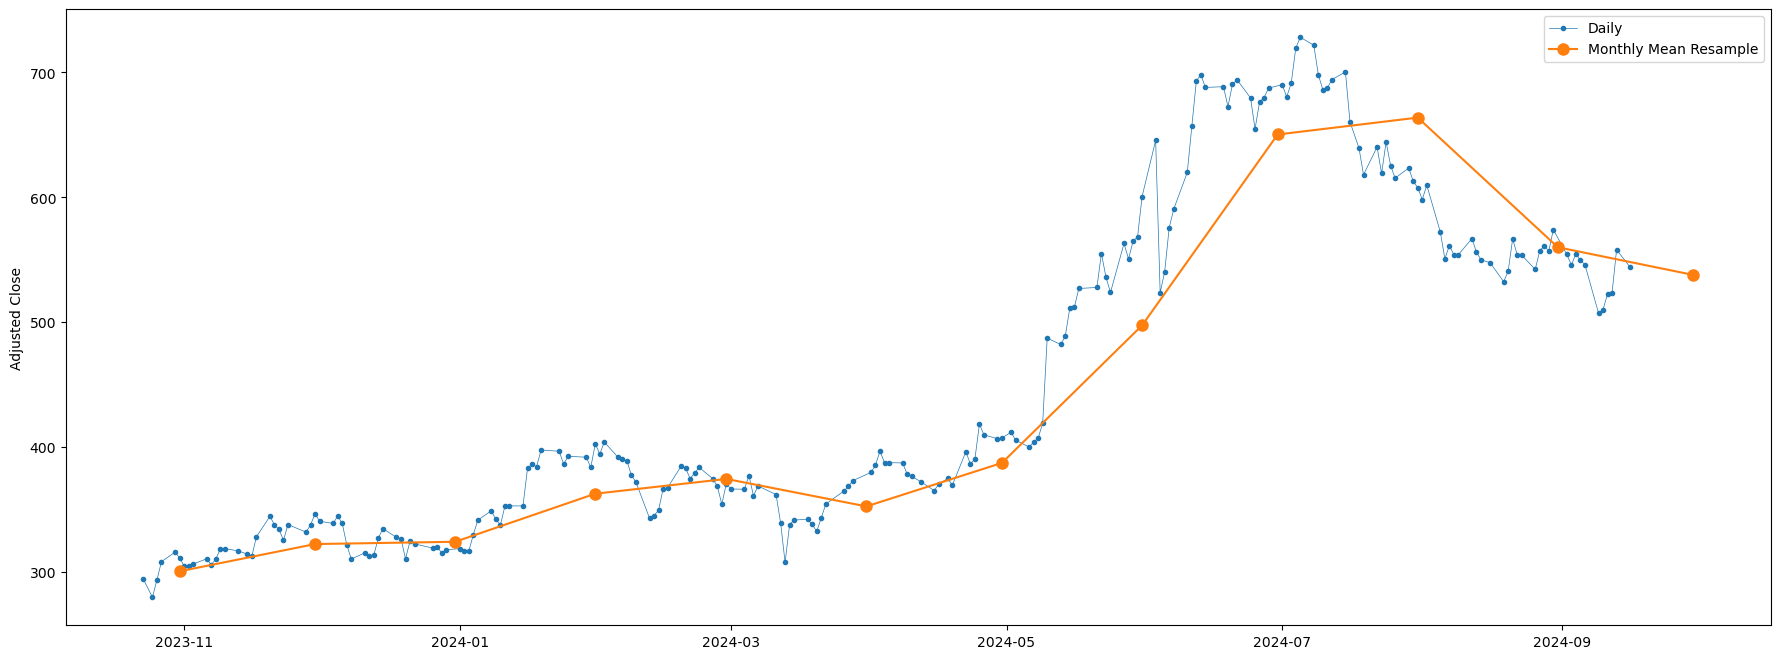

In [40]:
# Visualizing the Daily Adjusted Close and the Monthly Average resampled data
fig, ax = plt.subplots(figsize=(22, 8))
ax.plot(df_train['Adj Close'],marker='.', linestyle='-', linewidth=0.5, label='Daily')
ax.plot(df_train['Adj Close'].resample('M').mean(),marker='o', markersize=8, linestyle='-', label='Monthly Mean Resample')
ax.set_ylabel('Adjusted Close')
ax.legend()
plt.show()

* Both daily and monthly mean follow the same macroscopic trend.
* no clear trend or seasonality is there.

# 1. Linear Regression model

In [41]:
df_train = df_train.sort_index()
df_train.head()


Price,Adj Close,Close,High,Low,Open,Volume,MA10,MA50,MA200,RSI,daily_change,Year,Month,Weekday
Ticker,JWL.NS,JWL.NS,JWL.NS,JWL.NS,JWL.NS,JWL.NS,,,,,,,,
Date,,,,,,,,,,,,,,
2023-10-23,294.291351,295.299988,315.950012,294.950012,315.000000,632767,307.495007,321.028002,175.93850,39.891304,-0.048800,2023,October,Monday
2023-10-25,279.840881,280.799988,300.799988,280.549988,292.000000,731108,305.865005,321.937001,176.86075,31.635658,-0.049103,2023,October,Wednesday
2023-10-26,293.793030,294.799988,294.799988,266.799988,279.049988,1676552,304.150003,322.891001,177.84025,41.636691,0.049858,2023,October,Thursday
2023-10-27,308.442871,309.500000,309.500000,303.899994,309.500000,753321,303.305002,323.892001,178.87000,48.121498,0.049864,2023,October,Friday
2023-10-30,315.867432,316.950012,324.950012,313.149994,324.950012,2199581,303.805002,324.783001,179.95725,57.894740,0.024071,2023,October,Monday


In [42]:
# Prepare the features and target
df_train['Weekday'] = pd.Categorical(df_train['Weekday']).codes  # Encode Weekday if it's categorical
X = df_train[['MA10', 'MA50', 'MA200', 'RSI', 'daily_change', 'Weekday']]
y = df_train['Adj Close']
df_train.head()

Price,Adj Close,Close,High,Low,Open,Volume,MA10,MA50,MA200,RSI,daily_change,Year,Month,Weekday
Ticker,JWL.NS,JWL.NS,JWL.NS,JWL.NS,JWL.NS,JWL.NS,,,,,,,,
Date,,,,,,,,,,,,,,
2023-10-23,294.291351,295.299988,315.950012,294.950012,315.000000,632767,307.495007,321.028002,175.93850,39.891304,-0.048800,2023,October,1
2023-10-25,279.840881,280.799988,300.799988,280.549988,292.000000,731108,305.865005,321.937001,176.86075,31.635658,-0.049103,2023,October,4
2023-10-26,293.793030,294.799988,294.799988,266.799988,279.049988,1676552,304.150003,322.891001,177.84025,41.636691,0.049858,2023,October,2
2023-10-27,308.442871,309.500000,309.500000,303.899994,309.500000,753321,303.305002,323.892001,178.87000,48.121498,0.049864,2023,October,0
2023-10-30,315.867432,316.950012,324.950012,313.149994,324.950012,2199581,303.805002,324.783001,179.95725,57.894740,0.024071,2023,October,1


## Split and Fit LinearRegression

In [43]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [44]:
# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [45]:
# Backtest: Make predictions on test set
y_pred = model.predict(X_test)

## Back-Test Actual v/s Predicted

    Since we cannot use cross validation in our time series based datasets,as it can jumble the datasets during different folds.

    This is not true of time series data, where the time dimension of observations means that we cannot randomly split them into groups.

We can use backtesting method for time series.

    In backtesting we can create multiple train-test splits keeping in mind the temporal order of our data during splits . For example if I have dataset between Jan to Dec

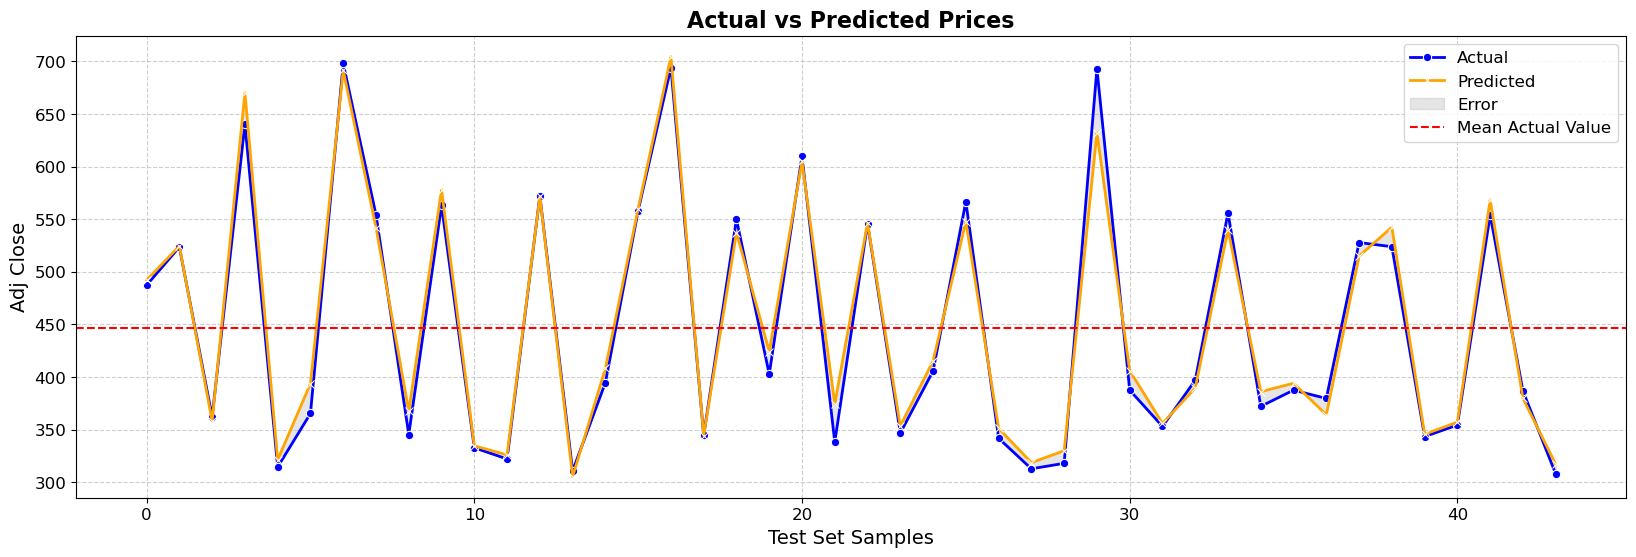

In [46]:
# Plot of actual vs predicted values
plt.figure(figsize=(20, 6))

y_test_1d = y_test.values.ravel()
y_pred_1d = y_pred.ravel()

# Plot actual vs predicted values
sns.lineplot(x=range(len(y_test_1d)), y=y_test_1d, label='Actual', marker='o', linewidth=2, color='blue')
sns.lineplot(x=range(len(y_test_1d)), y=y_pred_1d, label='Predicted', marker='x', linewidth=2, color='orange')
plt.fill_between(range(len(y_test_1d)), y_test_1d, y_pred_1d, color='gray', alpha=0.2, label='Error')
plt.axhline(y=y_test_1d.mean(), color='red', linestyle='--', linewidth=1.5, label='Mean Actual Value')

plt.legend(fontsize=12)
plt.title('Actual vs Predicted Prices', fontsize=16, fontweight='bold')
plt.xlabel('Test Set Samples', fontsize=14)
plt.ylabel('Adj Close', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Display the plot
plt.show()


After looking at how different cross validation mechanism works, we'll now use TimeSeriesSplit for our time series dataset. In time series, evaluating models on past data is called **Backtesting**. In some area such as meteorology, the word **hindcasting** is used for the same.

## Forecasting

In [47]:
# Forecast: Predict future prices
future_data = pd.DataFrame({
    'MA10': [230],  # Replace with future values
    'MA50': [225],
    'MA200': [220],
    'RSI': [50],
    'daily_change': [0.02],
    'Weekday': [3]  # Assume Wednesday
})
future_prediction = model.predict(future_data)
print(f"Forecasted Adj Close: {future_prediction[0]}")

Forecasted Adj Close: [241.4729487]


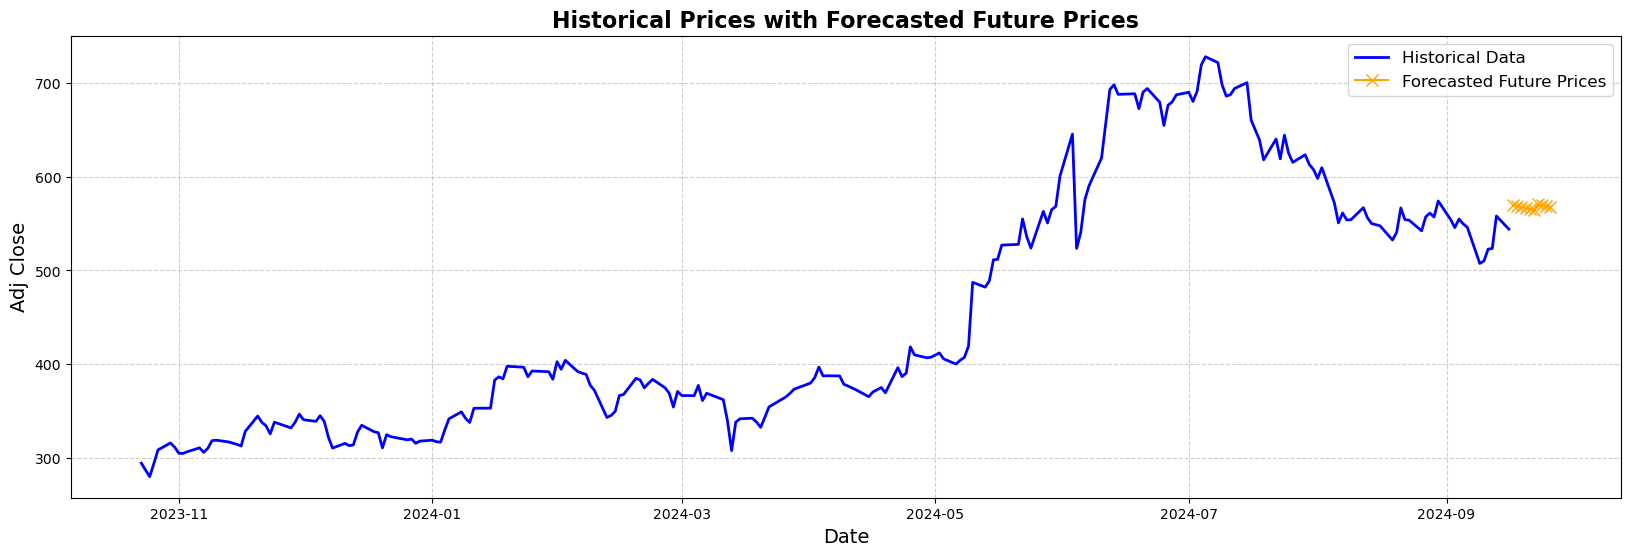


--- Forecasted Future Prices ---
2024-09-17: [569.78374336]
2024-09-18: [568.74528827]
2024-09-19: [567.70683317]
2024-09-20: [566.66837807]
2024-09-21: [565.62992298]
2024-09-22: [564.59146788]
2024-09-23: [570.82219846]
2024-09-24: [569.78374336]
2024-09-25: [568.74528827]
2024-09-26: [567.70683317]


In [48]:
forecast_days = 10
historical_data = df_train['Adj Close']

# Create a sequence of future dates for plotting
last_timestamp = historical_data.index[-1]

future_predictions = []
future_dates = []

for i in range(1, forecast_days + 1):
    future_data = pd.DataFrame({
        'MA10': [historical_data.iloc[-1] * 1.01],  # Example: Assume future values grow by 1%
        'MA50': [historical_data.iloc[-1] * 1.02],  # Example: Assume future values grow by 2%
        'MA200': [historical_data.iloc[-1] * 1.03],  # Example: Assume future values grow by 3%
        'RSI': [50],  # Assuming RSI remains constant
        'daily_change': [0.02],  # Assuming daily change remains constant
        'Weekday': [(historical_data.index[-1].weekday() + i) % 7]  # Cycle through weekdays
    })

    # Predict future price
    future_prediction = model.predict(future_data)
    future_predictions.append(future_prediction[0])

    # Get the future date
    future_date = last_timestamp + pd.DateOffset(days=i)
    future_dates.append(future_date)


plt.figure(figsize=(20, 6))
plt.plot(historical_data.index, historical_data, label='Historical Data', color='blue', linestyle='-', linewidth=2)
plt.plot(future_dates, future_predictions, label='Forecasted Future Prices', color='orange', linestyle='-', marker='x', markersize=8)

plt.title('Historical Prices with Forecasted Future Prices', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Adj Close', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

plt.show()

# Display the forecasted future prices for reference
print("\n--- Forecasted Future Prices ---")
for date, price in zip(future_dates, future_predictions):
    print(f"{date.strftime('%Y-%m-%d')}: {price}")


## Calculating evaluation metrics

- Mean Absolute Error (MAE)
- r2 Score
- Mean Absolute Percentage Error (MAPE)
- Root Mean Squared Error (RMSE)
- Symmetric Mean Absolute Percentage Error (SMAPE)

In [49]:
# Calculate the MAE
mae = mean_absolute_error(y_test, y_pred)
print('MAE: %.2f' % mae)

MAE: 11.75


In [50]:
# Calculate the r2 Score
r2 = r2_score(y_test, y_pred)
print("MAPE: %.2f%%"% r2)

MAPE: 0.98%


In [51]:
# Calculate the MAPE
mape = (abs((y_test - y_pred) / y_test)).mean() * 100
print("MAPE: %.2f%%"% mape)

MAPE: 2.66%


In [52]:
# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE: %.2f"% rmse)

RMSE: 16.16


In [53]:
# Calculate SMAPE
smape = (100/len(y_test)) * np.sum(2 * np.abs(y_pred - y_test) / (np.abs(y_test) + np.abs(y_pred)))
print("SMAPE: %.2f%%" % smape)

SMAPE: 2.64%


# 2. Random Forest Model

In [54]:
df_train = df_train.sort_index()
df_train.head()

Price,Adj Close,Close,High,Low,Open,Volume,MA10,MA50,MA200,RSI,daily_change,Year,Month,Weekday
Ticker,JWL.NS,JWL.NS,JWL.NS,JWL.NS,JWL.NS,JWL.NS,,,,,,,,
Date,,,,,,,,,,,,,,
2023-10-23,294.291351,295.299988,315.950012,294.950012,315.000000,632767,307.495007,321.028002,175.93850,39.891304,-0.048800,2023,October,1
2023-10-25,279.840881,280.799988,300.799988,280.549988,292.000000,731108,305.865005,321.937001,176.86075,31.635658,-0.049103,2023,October,4
2023-10-26,293.793030,294.799988,294.799988,266.799988,279.049988,1676552,304.150003,322.891001,177.84025,41.636691,0.049858,2023,October,2
2023-10-27,308.442871,309.500000,309.500000,303.899994,309.500000,753321,303.305002,323.892001,178.87000,48.121498,0.049864,2023,October,0
2023-10-30,315.867432,316.950012,324.950012,313.149994,324.950012,2199581,303.805002,324.783001,179.95725,57.894740,0.024071,2023,October,1


In [55]:
# Sort and prepare the data
df_train = df_train.sort_index()
df_train['Weekday'] = pd.Categorical(df_train['Weekday']).codes  # Encode Weekday if it's categorical
X = df_train[['MA10', 'MA50', 'MA200', 'RSI', 'daily_change', 'Weekday']]
y = df_train['Adj Close']


## Split and Fit Random Forest

In [56]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [57]:
# Initialize the Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=42)


In [58]:
# Train the model on the training data
rf_model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [59]:
# Backtest: Make predictions on the test set
y_pred = rf_model.predict(X_test)

In [60]:
# Optionally, display the feature importance
importances = rf_model.feature_importances_
print("Feature importances:", dict(zip(X.columns, importances)))

Feature importances: {('MA10', ''): 0.3820249420462003, ('MA50', ''): 0.3091967673425065, ('MA200', ''): 0.29267813724120867, ('RSI', ''): 0.00835058193469594, ('daily_change', ''): 0.006864169731701237, ('Weekday', ''): 0.0008854017036873624}


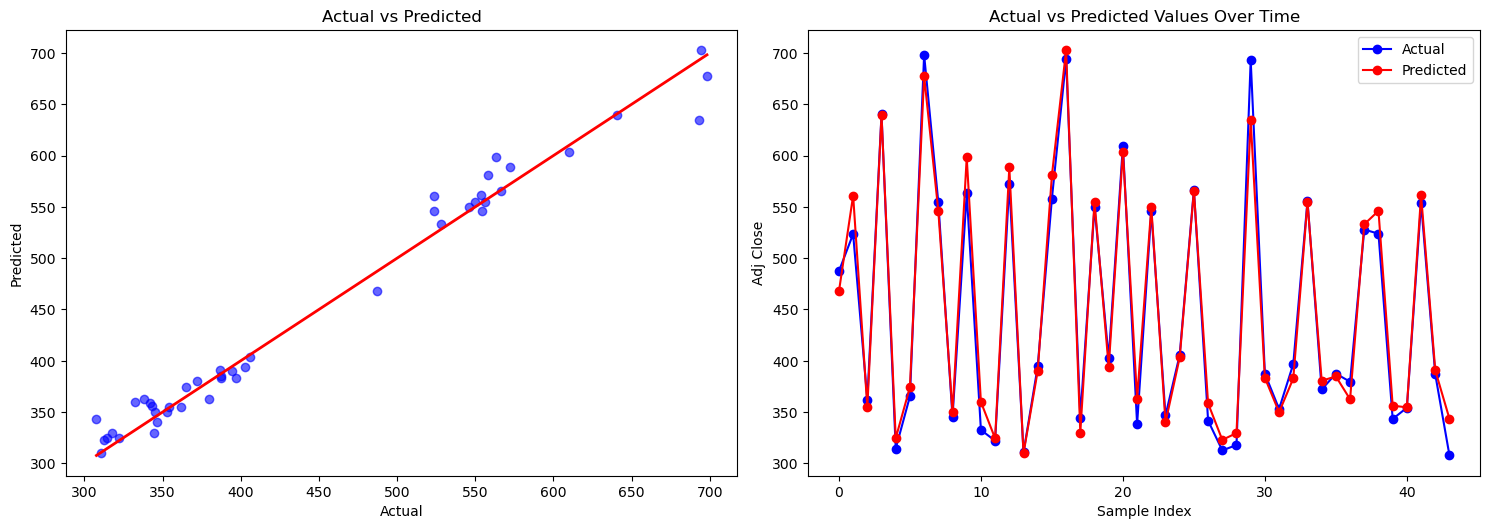

In [61]:
# Plotting
plt.figure(figsize=(15, 10))

# 1. Actual vs Predicted Plot
plt.subplot(2,2,1)
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.title('Actual vs Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')

# 2. Predicted vs. Actual Values Line Plot
plt.subplot(2,2,2)
plt.plot(y_test.values, label='Actual', color='blue', marker='o')
plt.plot(y_pred, label='Predicted', color='red', marker='o')
plt.title('Actual vs Predicted Values Over Time')
plt.xlabel('Sample Index')
plt.ylabel('Adj Close')
plt.legend()

plt.tight_layout()
plt.show()


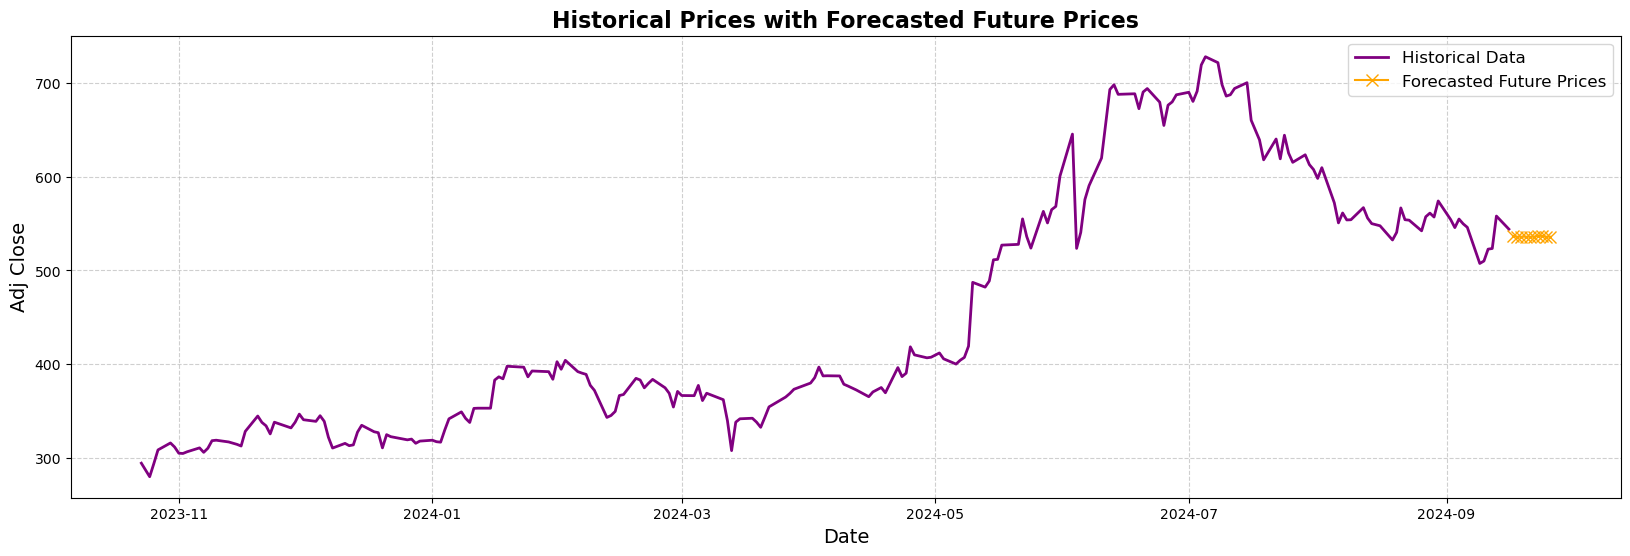


--- Forecasted Future Prices ---
2024-09-17: 536.69
2024-09-18: 536.04
2024-09-19: 536.00
2024-09-20: 536.02
2024-09-21: 536.02
2024-09-22: 536.02
2024-09-23: 537.22
2024-09-24: 536.69
2024-09-25: 536.04
2024-09-26: 536.00


In [62]:
# Plotting the actual vs predicted and forecasted future prices
forecast_days = 10
historical_data = df_train['Adj Close']
last_timestamp = historical_data.index[-1]

future_predictions = []
future_dates = []

# Generate future data and make predictions
for i in range(1, forecast_days + 1):
    future_data = pd.DataFrame({
        'MA10': [historical_data.iloc[-1] * 1.01],  # Example: Assume future values grow by 1%
        'MA50': [historical_data.iloc[-1] * 1.02],  # Example: Assume future values grow by 2%
        'MA200': [historical_data.iloc[-1] * 1.03],  # Example: Assume future values grow by 3%
        'RSI': [50],  # Assuming RSI remains constant
        'daily_change': [0.02],  # Assuming daily change remains constant
        'Weekday': [(historical_data.index[-1].weekday() + i) % 7]  # Cycle through weekdays
    })

    # Predict future price
    future_prediction = rf_model.predict(future_data)
    future_predictions.append(future_prediction[0])

    # Get the future date
    future_date = last_timestamp + pd.DateOffset(days=i)
    future_dates.append(future_date)

# Plot historical and forecasted data
plt.figure(figsize=(20, 6))
plt.plot(historical_data.index, historical_data, label='Historical Data', color='purple', linestyle='-', linewidth=2)
plt.plot(future_dates, future_predictions, label='Forecasted Future Prices', color='orange', linestyle='-', marker='x', markersize=8)

plt.title('Historical Prices with Forecasted Future Prices', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Adj Close', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

plt.show()

# Display the forecasted future prices for reference
print("\n--- Forecasted Future Prices ---")
for date, price in zip(future_dates, future_predictions):
    print(f"{date.strftime('%Y-%m-%d')}: {price:.2f}")

## Calculating evaluation metrics

- Mean Absolute Error (MAE)
- r2 Score
- Root Mean Squared Error (RMSE)

In [63]:
# Calculate the MAE
mae = mean_absolute_error(y_test, y_pred)
print('MAE: %.2f' % mae)

MAE: 12.40


In [64]:
# Calculate the r2 Score
r2 = r2_score(y_test, y_pred)
print("MAPE: %.2f%%"% r2)

MAPE: 0.98%


In [65]:
# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE: %.2f"% rmse)

RMSE: 17.23


**References**:

1. *Yahoo Finance API Documentation: [Yahoo Finance API - yfinance](https://pypi.org/project/yfinance/)*
2. *Linear Regression Resources: Scikit-learn Linear Regression Documentation: [Linear Model Documentation](https://scikit-learn.org/stable/modules/linear_model.html#linear-regression)*
3. *Random Forest Resources: Scikit-learn Random Forest Regressor Documentation: [Random Forest Regressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html)*
4. *Visualization Libraries: Matplotlib Documentation: [Matplotlib](https://matplotlib.org/stable/contents.html)*
5. *Seaborn Documentation: [Seaborn](https://seaborn.pydata.org/)*

In [66]:
#@title Convert ipynb to HTML in Colab
# First File > Download > Download .ipynb
# Upload ipynb
from google.colab import files
f = files.upload()

# Convert ipynb to html
import subprocess
file0 = list(f.keys())[0]
_ = subprocess.run(["pip", "install", "nbconvert"])
_ = subprocess.run(["jupyter", "nbconvert", file0, "--to", "html"])

# download the html
files.download(file0[:-5]+"html")

ModuleNotFoundError: No module named 'google.colab'